# SHAP Interpretability — PSD+LDA (Patient-Specific)

For each eligible patient (≥5 preictal windows), trains a PSD+LDA model
on the **first 60%** of data (chronological), then uses `shap.LinearExplainer`
to explain predictions on the **final 20% test set**.

**Features:** 18 channels × 5 frequency bands = 90 features
```
Bands:    delta(0.5–4Hz), theta(4–8Hz), alpha(8–13Hz), beta(13–30Hz), gamma(30–40Hz)
Channels: FP1-F7, F7-T7, T7-P7, P7-O1, FP1-F3, F3-C3, C3-P3, P3-O1,
          FP2-F4, F4-C4, C4-P4, P4-O2, FP2-F8, F8-T8, T8-P8, P8-O2, FZ-CZ, CZ-PZ
```

**Outputs:**
- Per-patient beeswarm plots → `D:/seizure_results/shap/per_patient/`
- Cross-patient band/channel importance → `D:/seizure_results/shap/`
- Patient×Band heatmap → `D:/seizure_results/shap/`
- SHAP values saved to JSON for paper reporting

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import warnings
warnings.filterwarnings('ignore')

from scipy.signal import welch
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

try:
    import shap
    print(f'shap version: {shap.__version__}')
except ImportError:
    raise ImportError('Run:  pip install shap')

import sys
sys.path.insert(0, 'D:/Code')
from data_utils import VALID_PATIENTS, DATA_DIR
from eval_utils import find_youden_threshold

# ── Config ──
FS          = 256
MIN_PRE_WIN = 5
OUT_DIR     = r'D:\seizure_results\shap'
PER_PT_DIR  = os.path.join(OUT_DIR, 'per_patient')
os.makedirs(PER_PT_DIR, exist_ok=True)

BANDS = [
    (0.5,  4,  'delta'),
    (4,    8,  'theta'),
    (8,   13,  'alpha'),
    (13,  30,  'beta'),
    (30,  40,  'gamma'),
]
BAND_NAMES = [b[2] for b in BANDS]

CHANNELS = [
    'FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1',
    'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1',
    'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2',
    'FP2-F8', 'F8-T8', 'T8-P8', 'P8-O2',
    'FZ-CZ',  'CZ-PZ',
]

# Feature order matches extract_psd: all 18 channels for delta, then theta, ...
# So feature[i] = CHANNELS[i % 18] in BAND_NAMES[i // 18]
FEATURE_NAMES = [f'{ch}_{band}' for band in BAND_NAMES for ch in CHANNELS]  # 90 features

print(f'Patients: {len(VALID_PATIENTS)}')
print(f'Features: {len(FEATURE_NAMES)}')
print(f'Output:   {OUT_DIR}')

shap version: 0.49.1
Patients: 23
Features: 90
Output:   D:\seizure_results\shap


In [2]:
# ── Helper Functions ──

def extract_psd(X):
    """Extract PSD band-power features. Returns (n_windows, 90)."""
    all_feats = []
    chunk_size = 500
    for i in range(0, len(X), chunk_size):
        chunk = X[i:i+chunk_size]
        freqs, pxx = welch(chunk, fs=FS, axis=-1, nperseg=512)
        band_feats = []
        for lo, hi, _ in BANDS:
            mask = (freqs >= lo) & (freqs <= hi)
            band_feats.append(pxx[:, :, mask].mean(axis=-1))  # (chunk, 18)
        all_feats.append(np.concatenate(band_feats, axis=1))  # (chunk, 90)
    return np.vstack(all_feats)


def run_patient_shap(patient_id):
    """
    For one patient:
    1. Load data, extract PSD features
    2. Chronological 60/20/20 split
    3. Train LDA on train set
    4. Compute SHAP values on test set via LinearExplainer
    Returns dict with shap_values, feature_names, y_test, y_prob, patient_id
    or None if skipped.
    """
    X_raw = np.load(os.path.join(DATA_DIR, f'{patient_id}_X.npy'))
    y     = np.load(os.path.join(DATA_DIR, f'{patient_id}_y.npy'))

    n_pre = int((y == 1).sum())
    if n_pre < MIN_PRE_WIN:
        return None, f'only {n_pre} preictal windows'

    n = len(y)
    train_end = int(n * 0.6)
    val_end   = int(n * 0.8)

    X_feat = extract_psd(X_raw)
    del X_raw

    X_train, y_train = X_feat[:train_end],        y[:train_end]
    X_val,   y_val   = X_feat[train_end:val_end], y[train_end:val_end]
    X_test,  y_test  = X_feat[val_end:],          y[val_end:]

    if (y_val  == 1).sum() == 0: return None, 'no preictal in val'
    if (y_test == 1).sum() == 0: return None, 'no preictal in test'
    if (y_train == 1).sum() == 0: return None, 'no preictal in train'

    # Train LDA
    lda = LinearDiscriminantAnalysis(solver='svd', priors=[0.5, 0.5])
    lda.fit(X_train, y_train)

    # Youden threshold on val
    val_prob = lda.predict_proba(X_val)[:, 1]
    threshold = find_youden_threshold(y_val, val_prob)

    # SHAP via LinearExplainer
    # background = training set mean (fast and accurate for linear models)
    background = shap.maskers.Independent(X_train, max_samples=200)
    explainer  = shap.LinearExplainer(lda, background, feature_perturbation='interventional')
    shap_vals  = explainer(X_test)  # Explanation object, .values shape (n_test, 90)

    test_prob = lda.predict_proba(X_test)[:, 1]

    return {
        'patient':       patient_id,
        'shap_values':   shap_vals.values,   # (n_test, 90)  — for class=1 (preictal)
        'base_value':    float(shap_vals.base_values[0]) if np.ndim(shap_vals.base_values) > 0 else float(shap_vals.base_values),
        'X_test':        X_test,
        'y_test':        y_test,
        'y_prob':        test_prob,
        'threshold':     threshold,
        'n_pre_test':    int((y_test == 1).sum()),
        'n_inter_test':  int((y_test == 0).sum()),
    }, None


print('Helper functions defined.')

Helper functions defined.


In [3]:
# ── Run All Patients ──
all_results = []
skipped     = []

for pt in VALID_PATIENTS:
    print(f'\n--- {pt} ---')
    result, reason = run_patient_shap(pt)
    if result is None:
        print(f'  [skip] {reason}')
        skipped.append((pt, reason))
    else:
        all_results.append(result)
        n_pre   = result['n_pre_test']
        n_inter = result['n_inter_test']
        mean_abs = np.abs(result['shap_values']).mean(axis=0)
        top3_idx = np.argsort(mean_abs)[::-1][:3]
        top3 = [(FEATURE_NAMES[i], mean_abs[i]) for i in top3_idx]
        print(f'  n_pre={n_pre}, n_inter={n_inter}')
        print(f'  Top-3 features: ' + ', '.join(f'{n}({v:.4f})' for n, v in top3))

print(f'\nDone. {len(all_results)} patients, {len(skipped)} skipped.')


--- chb01 ---
  n_pre=18, n_inter=136
  Top-3 features: FP1-F3_alpha(6.1245), C4-P4_delta(4.6572), FP1-F7_alpha(4.2516)

--- chb02 ---
  [skip] no preictal in test

--- chb03 ---
  n_pre=76, n_inter=24
  Top-3 features: F4-C4_beta(9.5871), P7-O1_delta(9.4454), P7-O1_beta(9.2140)

--- chb04 ---
  [skip] no preictal in test

--- chb05 ---
  [skip] no preictal in test

--- chb06 ---
  n_pre=257, n_inter=32
  Top-3 features: CZ-PZ_gamma(2.9153), T7-P7_gamma(2.5222), P3-O1_gamma(2.3587)

--- chb07 ---
  n_pre=148, n_inter=57
  Top-3 features: T7-P7_gamma(4.4402), P7-O1_gamma(2.8437), F7-T7_beta(2.8048)

--- chb08 ---
  n_pre=105, n_inter=13
  Top-3 features: FP1-F3_beta(3.7727), FP2-F8_gamma(3.2081), FP1-F3_gamma(2.4802)

--- chb09 ---
  [skip] no preictal in val

--- chb10 ---
  n_pre=255, n_inter=6
  Top-3 features: F4-C4_gamma(4.4160), FP2-F4_gamma(3.8135), P7-O1_beta(3.0030)

--- chb11 ---
  [skip] no preictal in train

--- chb12 ---
  n_pre=56, n_inter=0
  Top-3 features: P7-O1_delta(

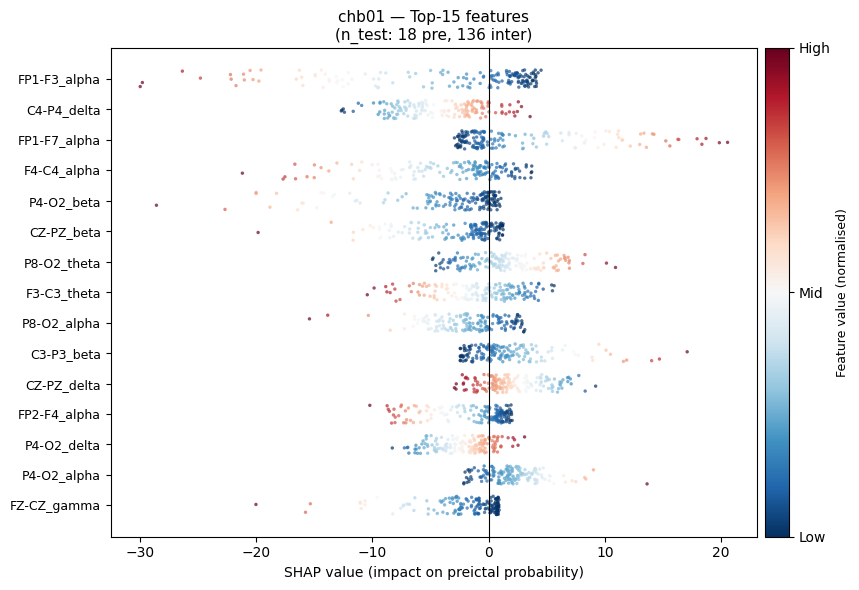

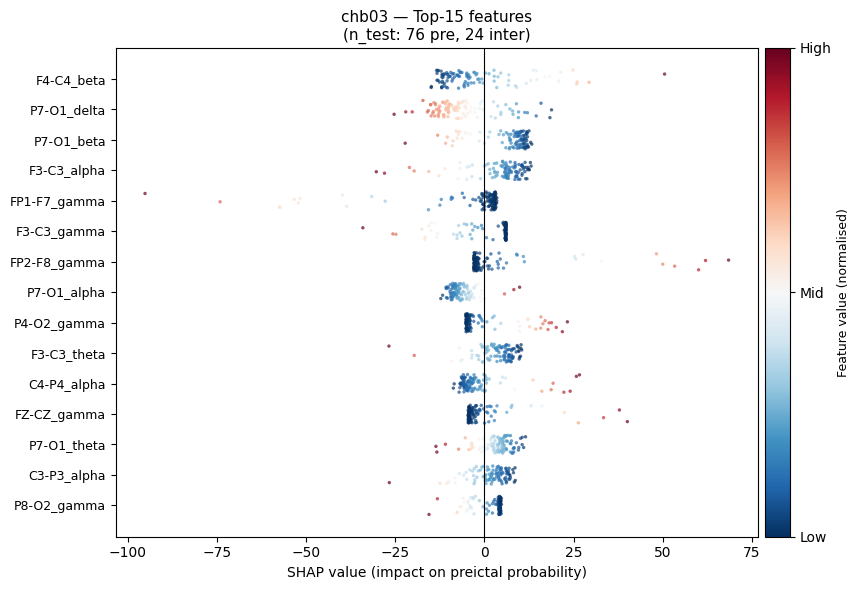

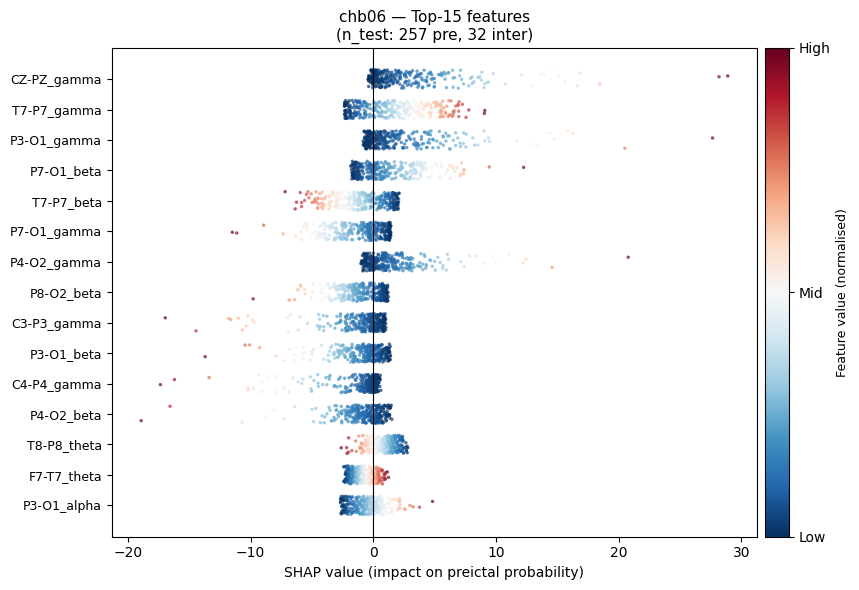

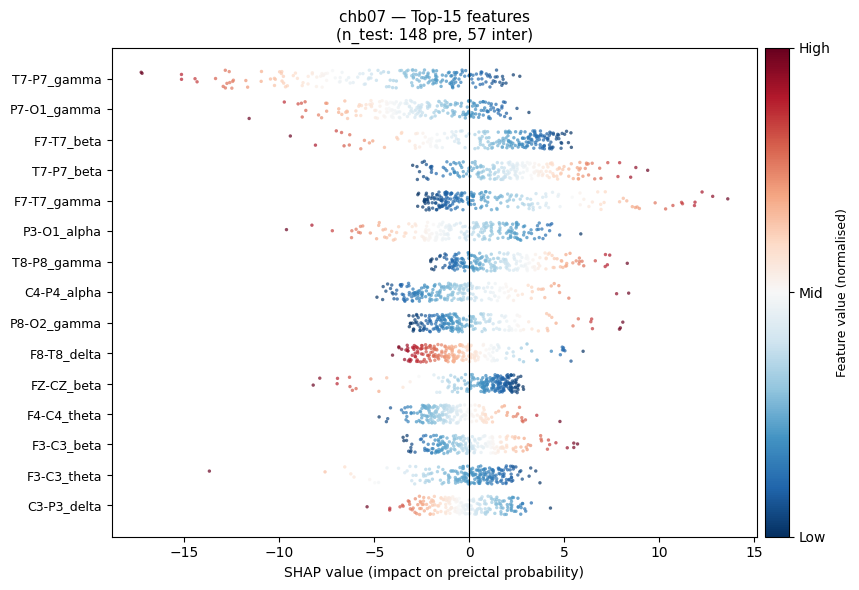

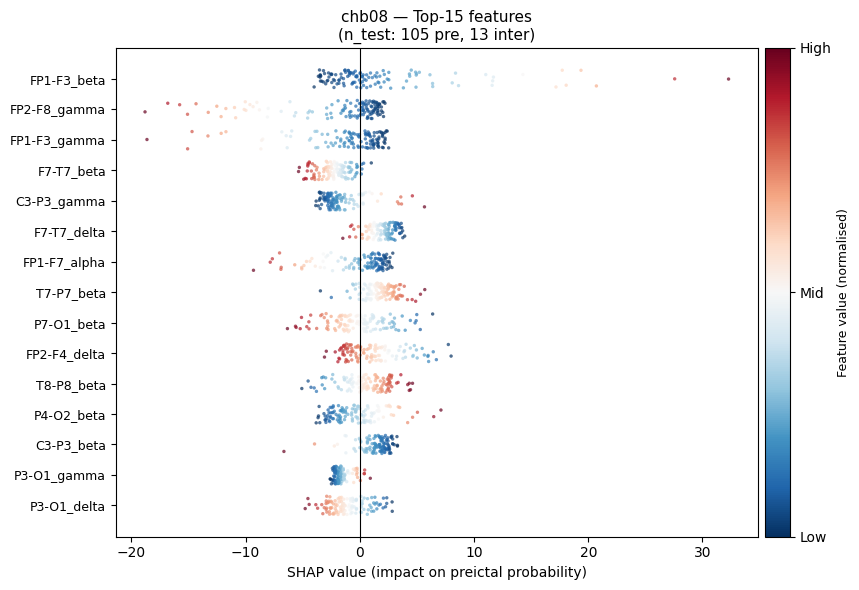

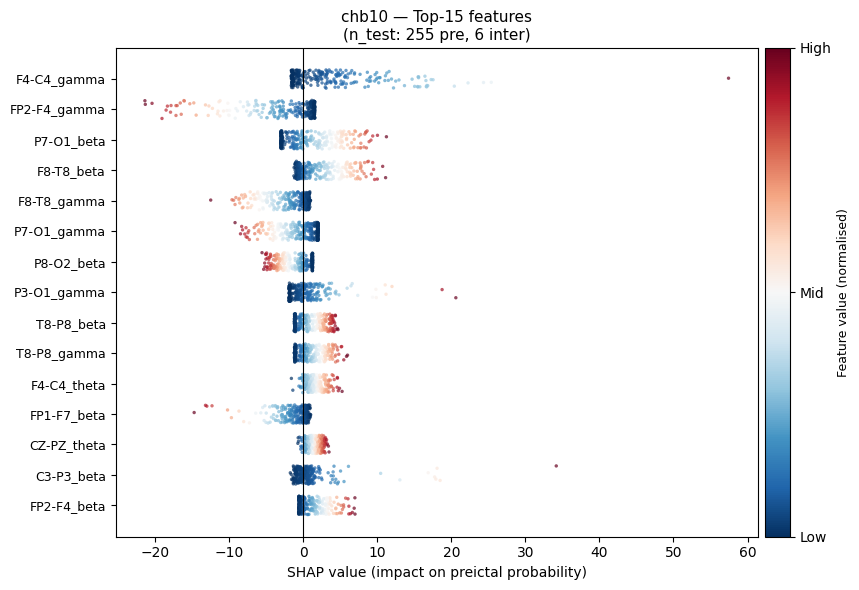

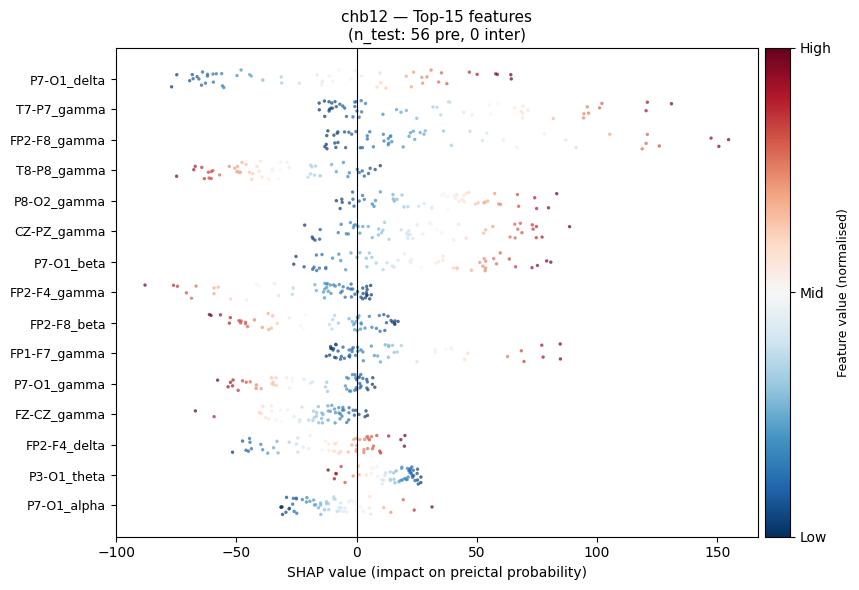

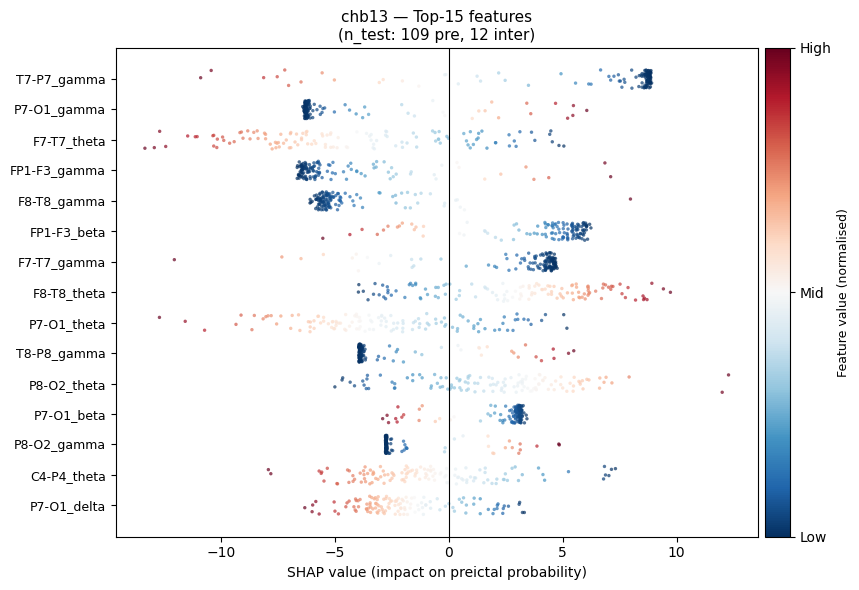

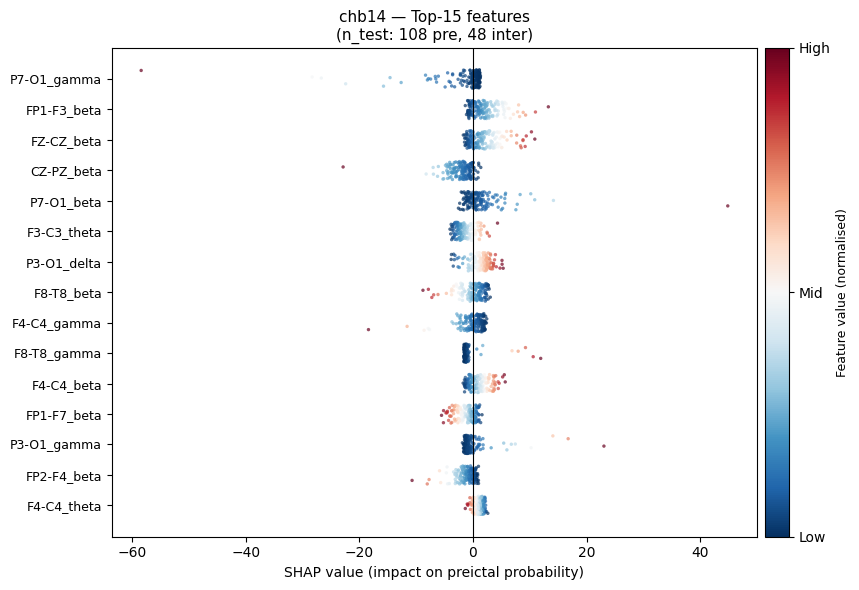

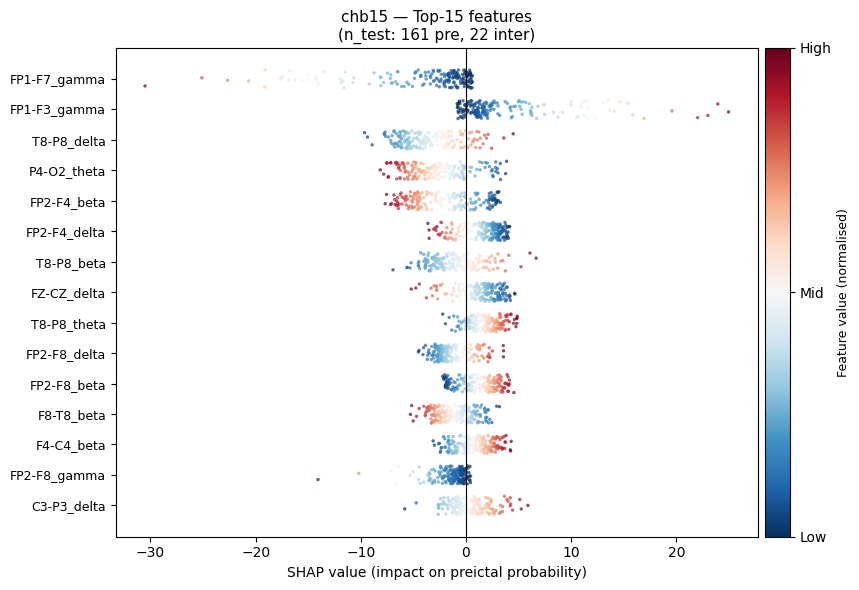

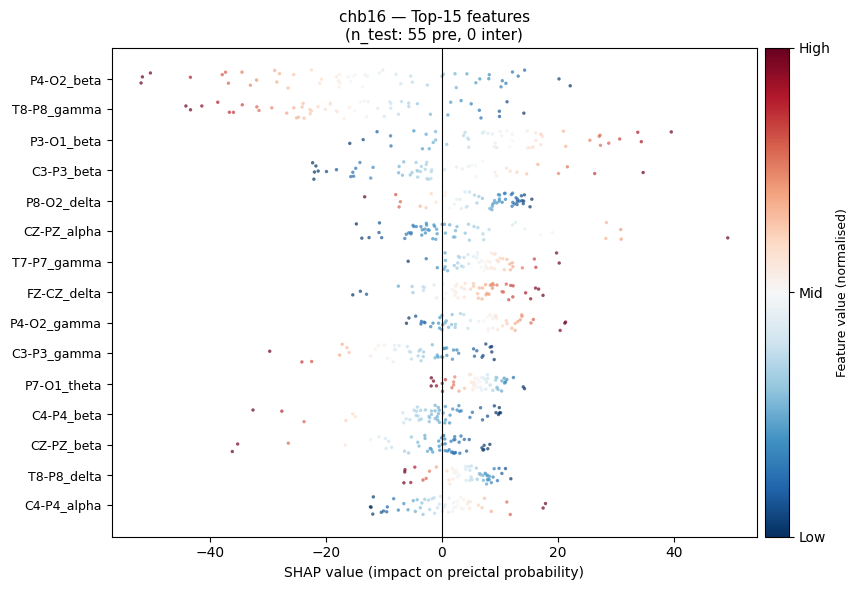

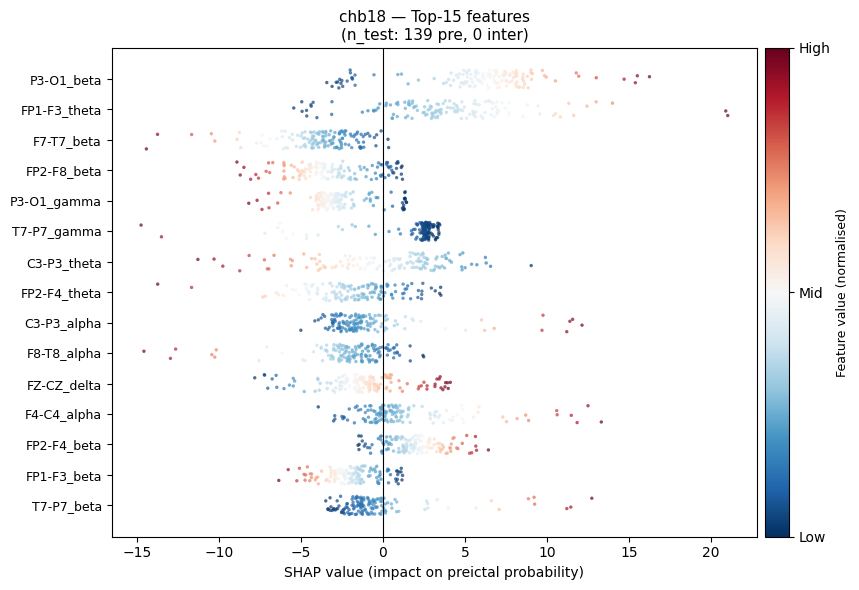

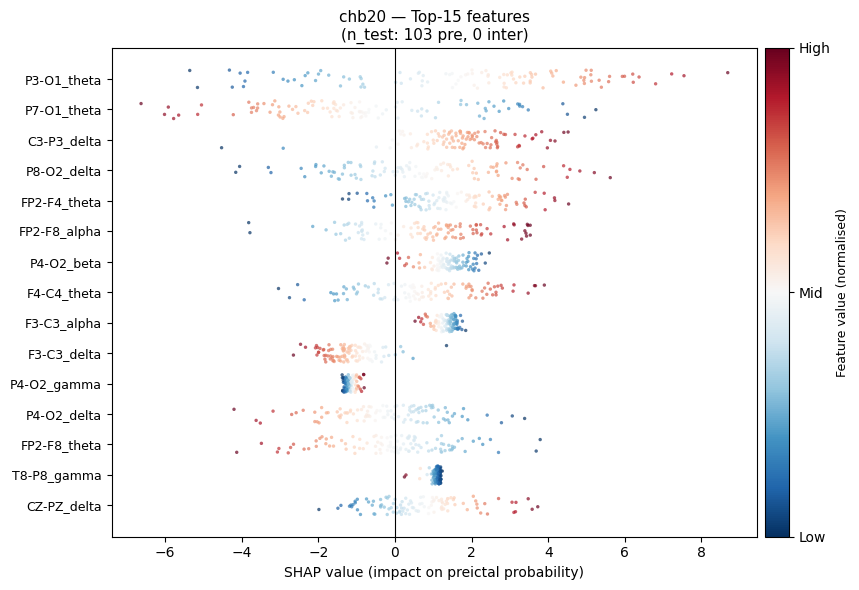

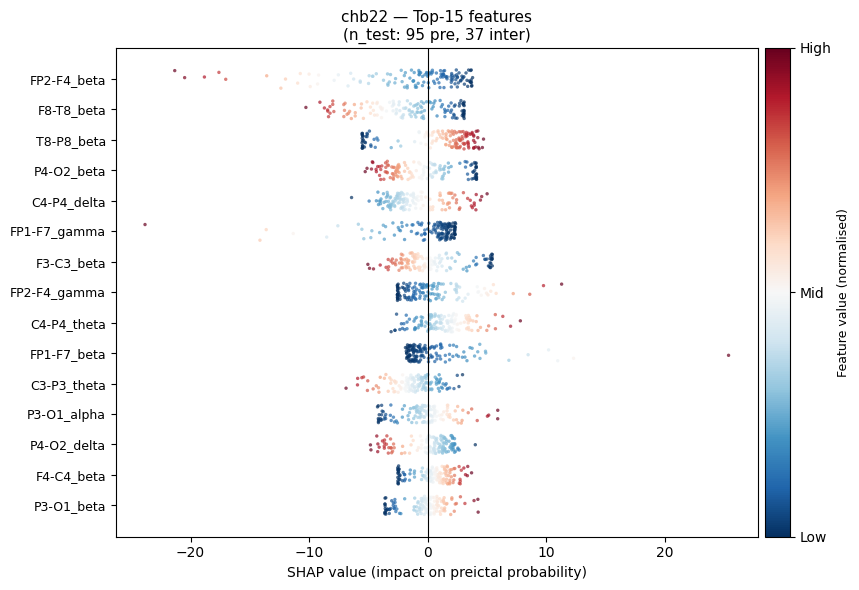

Beeswarm plots saved to D:\seizure_results\shap\per_patient


In [4]:
def plot_patient_beeswarm(result, top_n=15, save=True):
    pt       = result['patient']
    sv       = result['shap_values']           # (n_test, 90)
    X_test   = result['X_test']                # (n_test, 90)
    y_test   = result['y_test']

    mean_abs = np.abs(sv).mean(axis=0)
    top_idx  = np.argsort(mean_abs)[::-1][:top_n]
    top_idx  = top_idx[::-1]  # bottom-to-top for horizontal bar

    sv_top   = sv[:, top_idx]
    X_top    = X_test[:, top_idx]
    names    = [FEATURE_NAMES[i] for i in top_idx]

    fig, ax = plt.subplots(figsize=(9, 6))

    # Normalise feature values for colour mapping (ptp removed in NumPy 2.0)
    X_min  = X_top.min(axis=0, keepdims=True)
    X_max  = X_top.max(axis=0, keepdims=True)
    X_norm = (X_top - X_min) / (X_max - X_min + 1e-9)

    cmap   = plt.cm.RdBu_r
    jitter = np.random.default_rng(0).uniform(-0.3, 0.3, sv_top.shape)

    for feat_i in range(top_n):
        y_pos  = feat_i + jitter[:, feat_i]
        colors = cmap(X_norm[:, feat_i])
        ax.scatter(sv_top[:, feat_i], y_pos, c=colors, s=6, alpha=0.7, linewidths=0)

    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_yticks(range(top_n))
    ax.set_yticklabels(names, fontsize=9)
    ax.set_xlabel('SHAP value (impact on preictal probability)', fontsize=10)
    ax.set_title(f'{pt} — Top-{top_n} features\n'
                 f'(n_test: {result["n_pre_test"]} pre, {result["n_inter_test"]} inter)',
                 fontsize=11)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, 1))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, pad=0.01)
    cbar.set_label('Feature value (normalised)', fontsize=9)
    cbar.set_ticks([0, 0.5, 1])
    cbar.set_ticklabels(['Low', 'Mid', 'High'])

    plt.tight_layout()
    if save:
        path = os.path.join(PER_PT_DIR, f'{pt}_beeswarm.png')
        plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

for res in all_results:
    plot_patient_beeswarm(res)

print(f'Beeswarm plots saved to {PER_PT_DIR}')

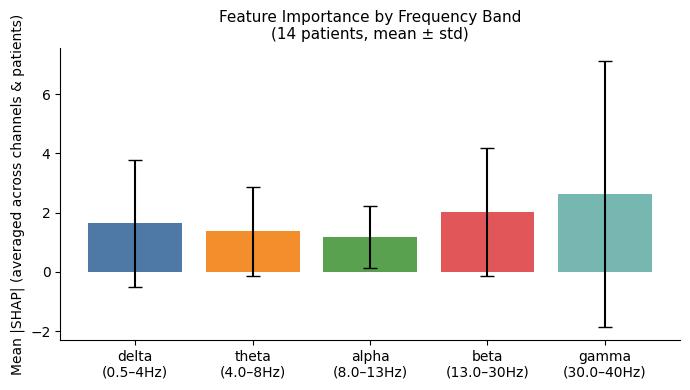


Band importance (mean ± std across patients):
  delta  (0.5–4Hz): 1.63759 ± 2.15175
  theta  (4.0–8Hz): 1.37860 ± 1.50039
  alpha  (8.0–13Hz): 1.18316 ± 1.05215
  beta   (13.0–30Hz): 2.02417 ± 2.14728
  gamma  (30.0–40Hz): 2.63339 ± 4.48159


In [5]:
# ── Cross-Patient: Importance by Frequency Band ──
# For each patient, aggregate mean |SHAP| across all channels per band.
# Then average across patients.

n_bands    = len(BAND_NAMES)
n_channels = len(CHANNELS)

# band_importance[patient_idx, band_idx] = mean |SHAP| for that band
band_mat = np.zeros((len(all_results), n_bands))

for pi, res in enumerate(all_results):
    sv = res['shap_values']       # (n_test, 90)
    mean_abs = np.abs(sv).mean(axis=0)  # (90,)
    for bi in range(n_bands):
        # Features for band bi: indices [bi*18 : (bi+1)*18]
        band_mat[pi, bi] = mean_abs[bi * n_channels: (bi + 1) * n_channels].mean()

band_mean = band_mat.mean(axis=0)
band_std  = band_mat.std(axis=0, ddof=1)

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(n_bands)
bars = ax.bar(x, band_mean, yerr=band_std, capsize=5,
              color=['#4e79a7', '#f28e2b', '#59a14f', '#e15759', '#76b7b2'],
              error_kw={'linewidth': 1.5})
ax.set_xticks(x)
ax.set_xticklabels(
    [f'{n}\n({lo:.1f}–{hi}Hz)' for (lo, hi, n) in BANDS],
    fontsize=10
)
ax.set_ylabel('Mean |SHAP| (averaged across channels & patients)', fontsize=10)
ax.set_title(f'Feature Importance by Frequency Band\n'
             f'({len(all_results)} patients, mean ± std)', fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'band_importance.png'), dpi=200, bbox_inches='tight')
plt.show()

print('\nBand importance (mean ± std across patients):')
for i, (lo, hi, name) in enumerate(BANDS):
    print(f'  {name:6s} ({lo:.1f}–{hi}Hz): {band_mean[i]:.5f} ± {band_std[i]:.5f}')

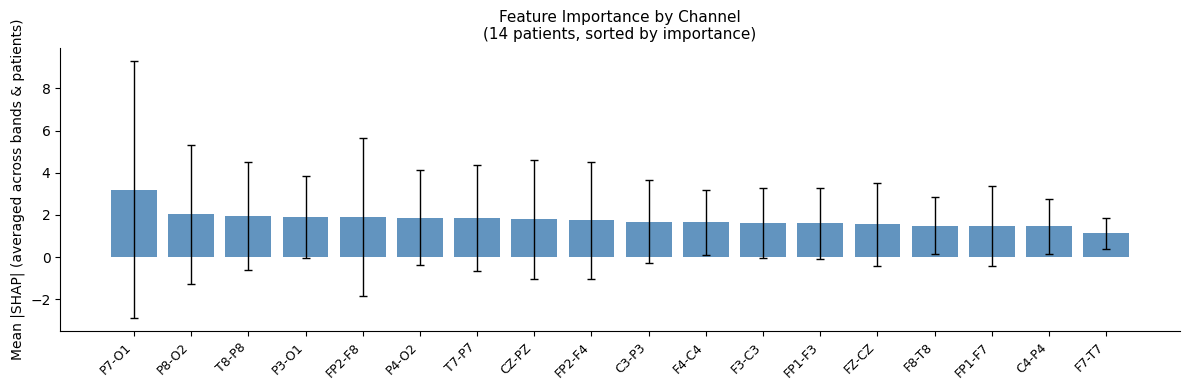

In [6]:
# ── Cross-Patient: Importance by Channel ──

ch_mat = np.zeros((len(all_results), n_channels))
for pi, res in enumerate(all_results):
    sv = res['shap_values']       # (n_test, 90)
    mean_abs = np.abs(sv).mean(axis=0)  # (90,)
    for ci in range(n_channels):
        # Features for channel ci: indices [ci, ci+18, ci+36, ci+54, ci+72]
        band_indices = [bi * n_channels + ci for bi in range(n_bands)]
        ch_mat[pi, ci] = mean_abs[band_indices].mean()

ch_mean = ch_mat.mean(axis=0)
ch_std  = ch_mat.std(axis=0, ddof=1)
ch_order = np.argsort(ch_mean)[::-1]  # sorted by importance

fig, ax = plt.subplots(figsize=(12, 4))
x = np.arange(n_channels)
ax.bar(x, ch_mean[ch_order], yerr=ch_std[ch_order], capsize=3,
       color='steelblue', alpha=0.85, error_kw={'linewidth': 1})
ax.set_xticks(x)
ax.set_xticklabels([CHANNELS[i] for i in ch_order], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Mean |SHAP| (averaged across bands & patients)', fontsize=10)
ax.set_title(f'Feature Importance by Channel\n'
             f'({len(all_results)} patients, sorted by importance)', fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'channel_importance.png'), dpi=200, bbox_inches='tight')
plt.show()

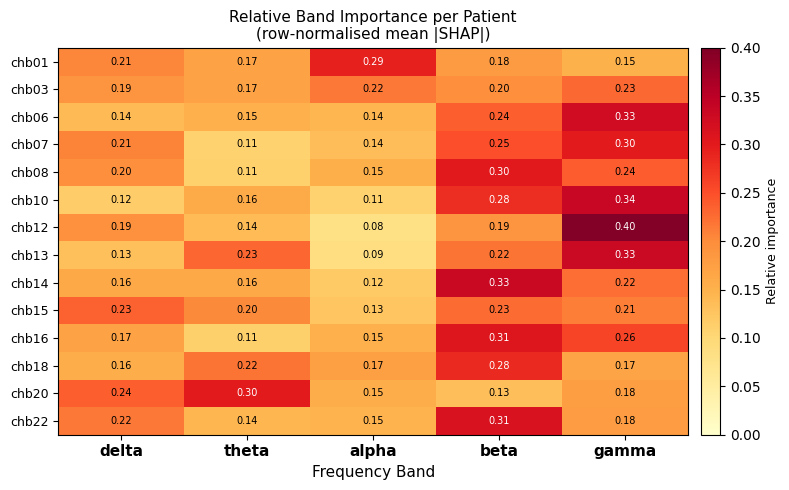

Heatmap saved.


In [7]:
# ── Patient × Band Heatmap ──
# Rows = patients, Cols = frequency bands
# Cell = normalised band importance per patient (to compare across patients)

# Normalise each patient's row so values sum to 1 (relative importance)
band_mat_norm = band_mat / (band_mat.sum(axis=1, keepdims=True) + 1e-12)
patient_labels = [r['patient'] for r in all_results]

fig, ax = plt.subplots(figsize=(8, max(5, len(all_results) * 0.35)))
im = ax.imshow(band_mat_norm, aspect='auto', cmap='YlOrRd', vmin=0, vmax=0.4)

ax.set_xticks(range(n_bands))
ax.set_xticklabels(BAND_NAMES, fontsize=11, fontweight='bold')
ax.set_yticks(range(len(patient_labels)))
ax.set_yticklabels(patient_labels, fontsize=9)
ax.set_xlabel('Frequency Band', fontsize=11)
ax.set_title('Relative Band Importance per Patient\n(row-normalised mean |SHAP|)', fontsize=11)

# Annotate cells
for i in range(len(patient_labels)):
    for j in range(n_bands):
        v = band_mat_norm[i, j]
        color = 'white' if v > 0.28 else 'black'
        ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=7, color=color)

cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label('Relative importance', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'patient_band_heatmap.png'), dpi=200, bbox_inches='tight')
plt.show()
print(f'Heatmap saved.')

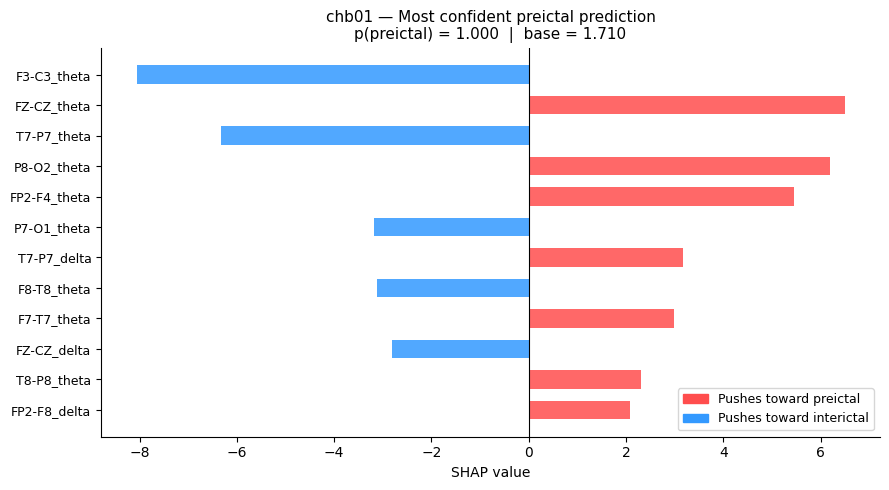

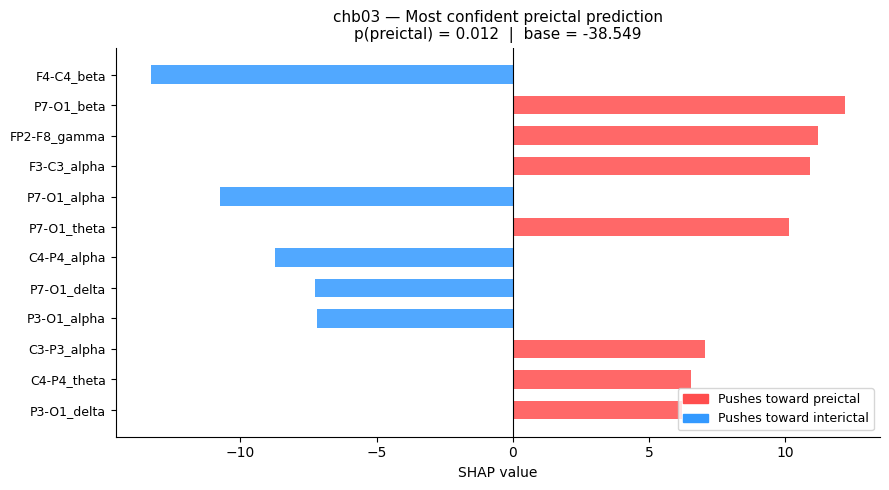

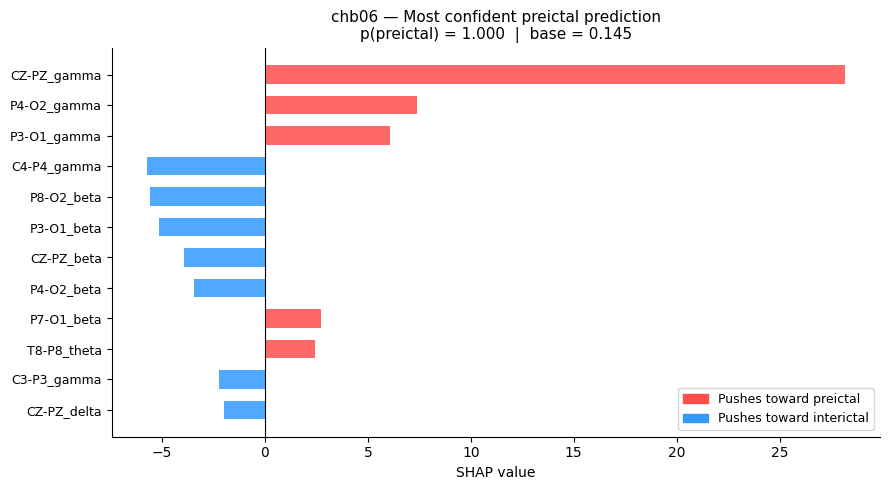

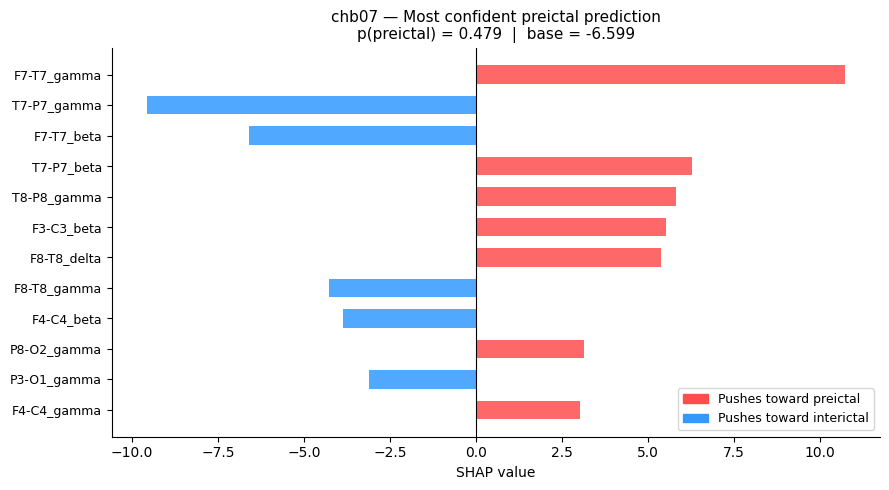

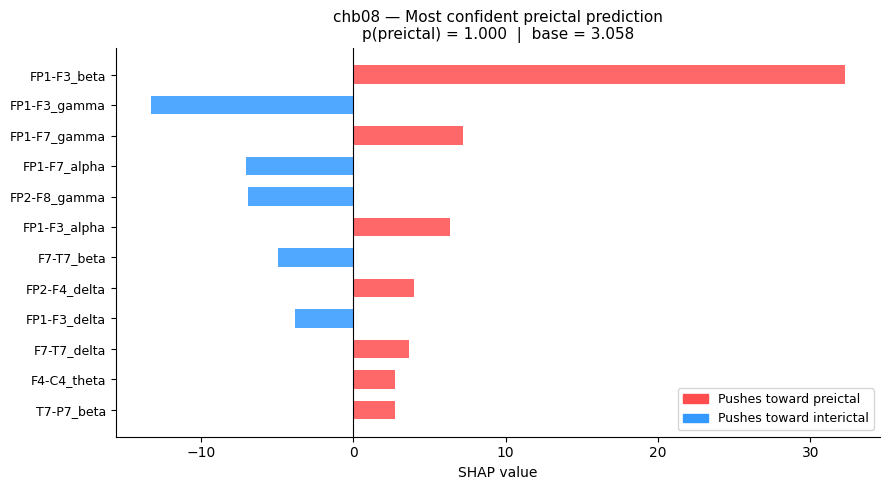

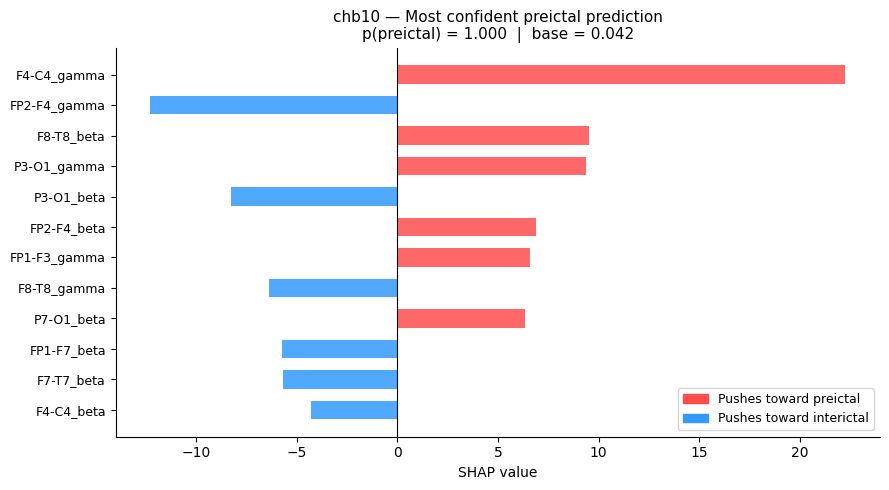

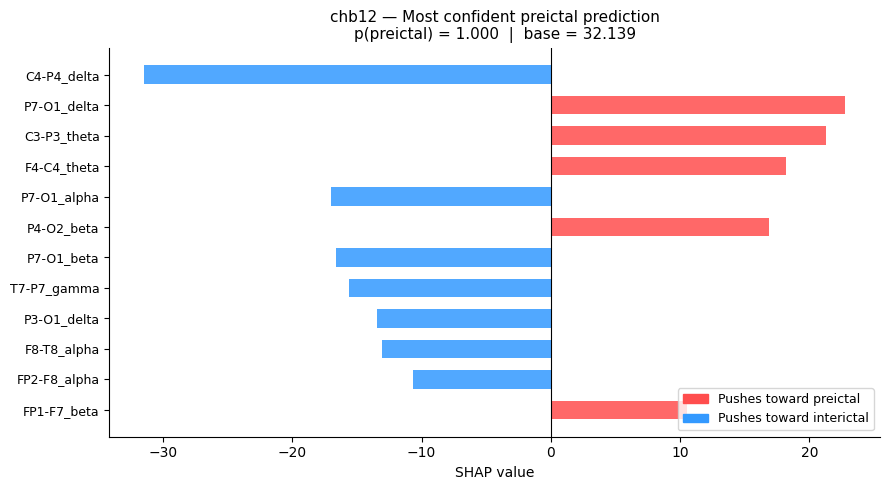

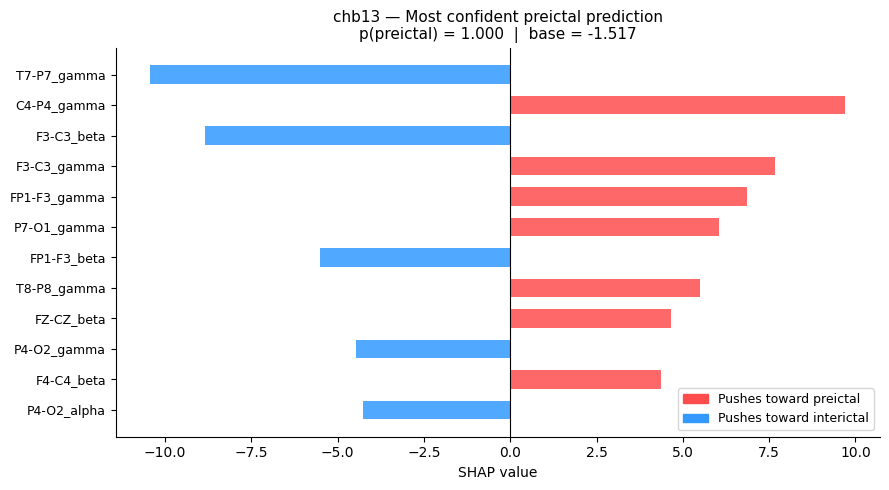

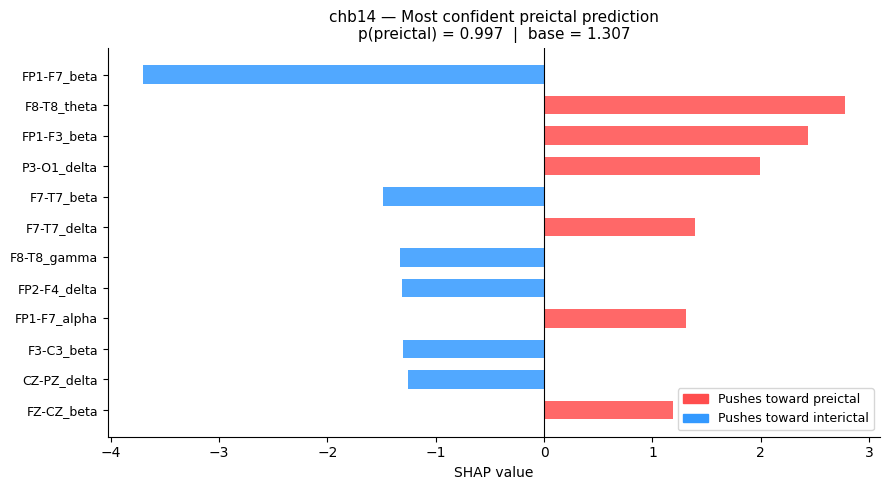

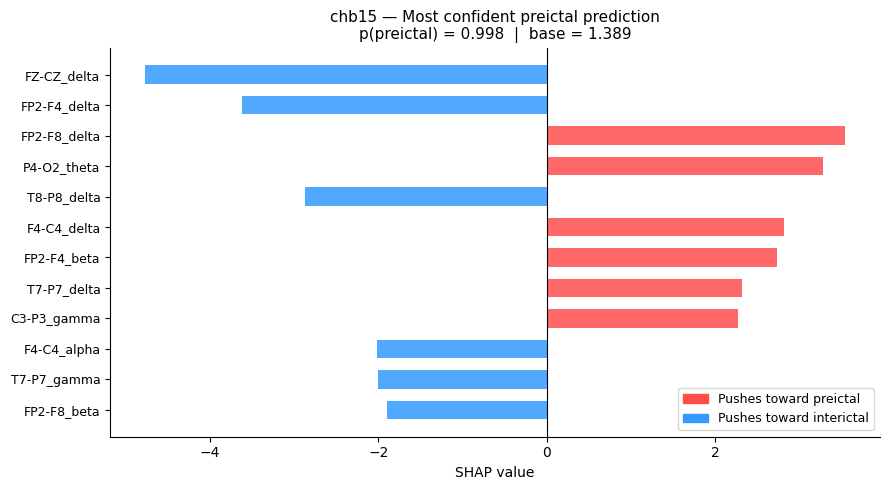

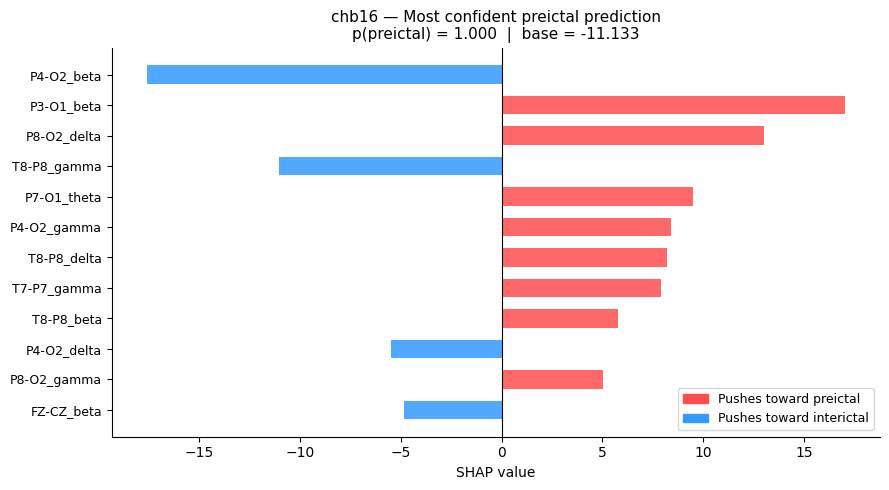

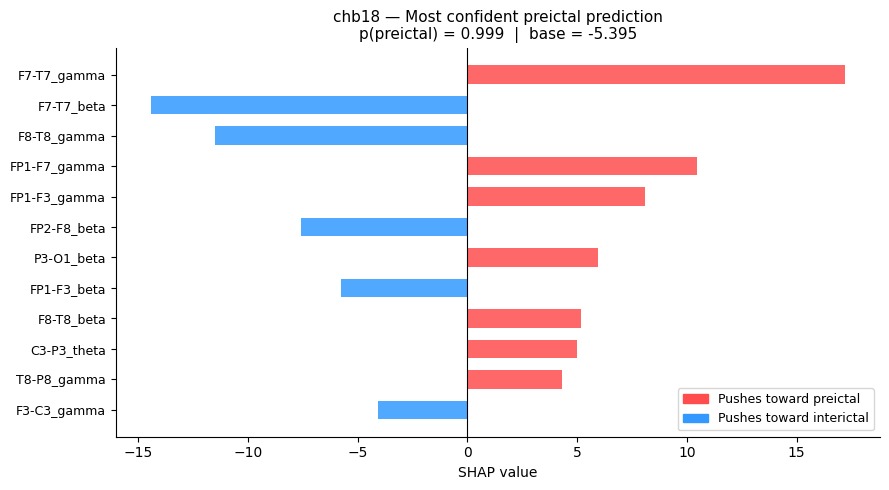

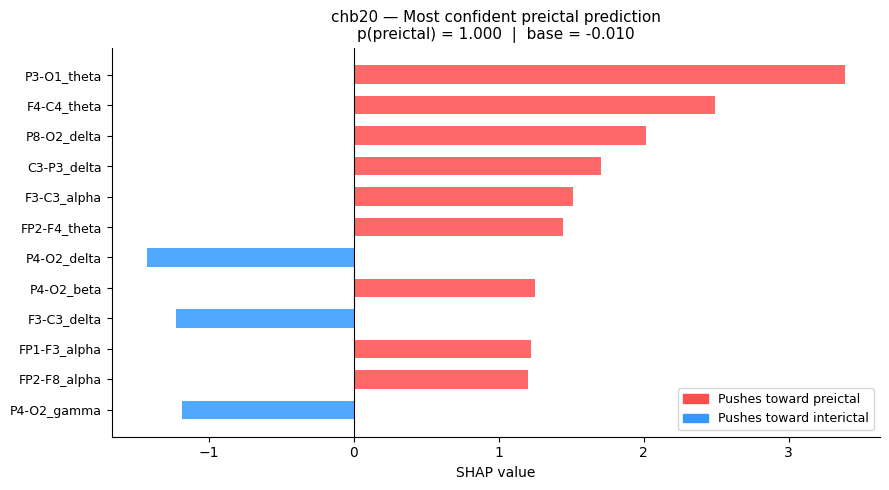

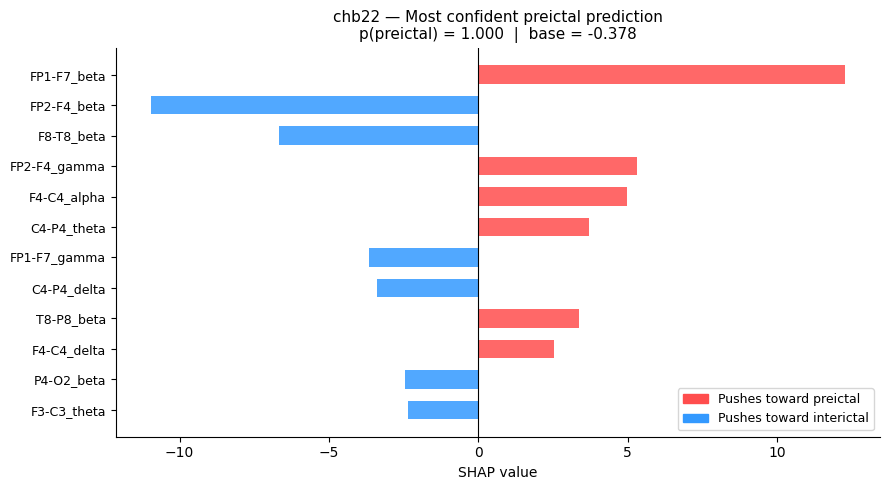

Waterfall plots saved to D:\seizure_results\shap\per_patient


In [8]:
# ── Waterfall Plot for Most Confident Preictal Window (per patient) ──
# Picks the test window with highest predicted probability among true preictal windows.
# Shows how individual features contributed to that single prediction.

def plot_waterfall(result, top_n=12, save=True):
    pt     = result['patient']
    sv     = result['shap_values']   # (n_test, 90)
    y_test = result['y_test']
    y_prob = result['y_prob']
    base   = result['base_value']

    # Pick most confidently predicted preictal window
    pre_mask = (y_test == 1)
    if pre_mask.sum() == 0:
        return
    best_idx = np.where(pre_mask)[0][np.argmax(y_prob[pre_mask])]

    sv_single = sv[best_idx]                    # (90,)
    abs_sv    = np.abs(sv_single)
    top_idx   = np.argsort(abs_sv)[::-1][:top_n]
    top_idx   = top_idx[::-1]  # bottom-to-top

    names  = [FEATURE_NAMES[i] for i in top_idx]
    values = sv_single[top_idx]
    colors = ['#ff4d4d' if v > 0 else '#3399ff' for v in values]

    fig, ax = plt.subplots(figsize=(9, 5))
    y_pos = np.arange(top_n)
    ax.barh(y_pos, values, color=colors, height=0.6, alpha=0.85)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(names, fontsize=9)
    ax.set_xlabel('SHAP value', fontsize=10)
    ax.set_title(
        f'{pt} — Most confident preictal prediction\n'
        f'p(preictal) = {y_prob[best_idx]:.3f}  |  base = {base:.3f}',
        fontsize=11
    )
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Patches for legend
    from matplotlib.patches import Patch
    ax.legend(handles=[
        Patch(color='#ff4d4d', label='Pushes toward preictal'),
        Patch(color='#3399ff', label='Pushes toward interictal'),
    ], loc='lower right', fontsize=9)

    plt.tight_layout()
    if save:
        path = os.path.join(PER_PT_DIR, f'{pt}_waterfall.png')
        plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

for res in all_results:
    plot_waterfall(res)

print(f'Waterfall plots saved to {PER_PT_DIR}')

In [9]:
# ── Save Summary Statistics to JSON (for paper) ──

summary = {
    'n_patients': len(all_results),
    'skipped':    [(pt, reason) for pt, reason in skipped],
    'band_importance': {
        name: {'mean': float(band_mean[i]), 'std': float(band_std[i])}
        for i, (_, _, name) in enumerate(BANDS)
    },
    'channel_importance': {
        CHANNELS[i]: {'mean': float(ch_mean[i]), 'std': float(ch_std[i])}
        for i in range(n_channels)
    },
    'per_patient_band': {
        res['patient']: {
            BAND_NAMES[bi]: float(band_mat_norm[pi, bi])
            for bi in range(n_bands)
        }
        for pi, res in enumerate(all_results)
    }
}

save_path = os.path.join(OUT_DIR, 'shap_summary.json')
with open(save_path, 'w') as f:
    json.dump(summary, f, indent=2)
print(f'Summary saved to {save_path}')

# Quick print for paper
print('\nBand Importance (for paper):')
sorted_bands = sorted(summary['band_importance'].items(),
                      key=lambda x: -x[1]['mean'])
for name, vals in sorted_bands:
    print(f'  {name:6s}: {vals["mean"]:.5f} ± {vals["std"]:.5f}')

print('\nTop-5 Channels:')
sorted_ch = sorted(summary['channel_importance'].items(),
                   key=lambda x: -x[1]['mean'])[:5]
for ch, vals in sorted_ch:
    print(f'  {ch:10s}: {vals["mean"]:.5f} ± {vals["std"]:.5f}')

Summary saved to D:\seizure_results\shap\shap_summary.json

Band Importance (for paper):
  gamma : 2.63339 ± 4.48159
  beta  : 2.02417 ± 2.14728
  delta : 1.63759 ± 2.15175
  theta : 1.37860 ± 1.50039
  alpha : 1.18316 ± 1.05215

Top-5 Channels:
  P7-O1     : 3.20483 ± 6.11137
  P8-O2     : 2.02086 ± 3.30692
  T8-P8     : 1.93954 ± 2.56668
  P3-O1     : 1.91816 ± 1.94632
  FP2-F8    : 1.89849 ± 3.72996
